<a href="https://colab.research.google.com/github/balrajparsi/balrajparsi/blob/main/pixelcnn_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PixelCNN with Mixture Distribution Output on Fashion MNIST

**Balraj Parsi**
**MSAI-630-M40: Generative AI with Large Language Models**
**Residency Day 2, Project 2**

This notebook builds a PixelCNN using TensorFlow Probability's built-in distribution, trained on Fashion MNIST with integer pixel values in the range [0, 255]. The network outputs a mixture of logistics distribution per pixel, and we generate new images by sampling from that learned distribution.

**Runtime:** Use **A100 GPU** for fastest training. Go to **Runtime > Change runtime type > A100 GPU**. If A100 is unavailable on your Colab tier, T4 GPU works as a fallback (just slower).

In [ ]:
# Verify GPU and install dependencies
import subprocess
gpu_check = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if gpu_check.returncode != 0:
    raise RuntimeError("No GPU! Go to Runtime > Change runtime type > A100 GPU")
# Print GPU name
for line in gpu_check.stdout.split('\n'):
    if 'A100' in line or 'T4' in line or 'V100' in line or 'L4' in line:
        print(line.strip())
        break

!pip install tensorflow-probability --quiet

import tensorflow as tf
print(f"TensorFlow {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus[0].name}" if gpus else "NO GPU DETECTED")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
TensorFlow 2.19.0
GPU: /physical_device:GPU:0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras import datasets, layers, models, optimizers, callbacks
import tensorflow_probability as tfp

print(f"TensorFlow Probability {tfp.__version__}")

TensorFlow Probability 0.25.0


## 0. Parameters

In [ ]:
IMAGE_SIZE = 32       # Resize Fashion MNIST from 28x28 to 32x32
N_COMPONENTS = 5     # Number of logistic components in the mixture
EPOCHS = 50          # Training epochs
BATCH_SIZE = 128     # Batch size

## 1. Prepare the Data

Fashion MNIST is loaded directly from Keras (no manual download needed). The key requirement is that **pixel values remain as integers in [0, 255]**, not normalized to [0, 1]. The PixelCNN mixture of logistics distribution expects raw pixel intensities because it models the discrete pixel distribution directly.

In [ ]:
# Load Fashion MNIST (auto-downloads ~30MB on first run)
(x_train, _), (x_test, _) = datasets.fashion_mnist.load_data()

print(f"Training set: {x_train.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Dtype: {x_train.dtype}")

Training set: (60000, 28, 28)
Pixel range: [0, 255]
Dtype: uint8


In [ ]:
# Preprocess: add channel dim and resize to 32x32
# IMPORTANT: keep pixel values as integers in [0, 255]
# PixelCNN's mixture of logistics models discrete pixel intensities directly

def preprocess(imgs):
    imgs = np.expand_dims(imgs, -1)                              # (N, 28, 28) -> (N, 28, 28, 1)
    imgs = tf.image.resize(imgs, (IMAGE_SIZE, IMAGE_SIZE)).numpy()  # -> (N, 32, 32, 1)
    return imgs

input_data = preprocess(x_train)

print(f"Preprocessed shape: {input_data.shape}")
print(f"Pixel range after resize: [{input_data.min():.1f}, {input_data.max():.1f}]")
print(f"Dtype: {input_data.dtype}")

Preprocessed shape: (60000, 32, 32, 1)
Pixel range after resize: [0.0, 255.0]
Dtype: float32


Training samples (Fashion MNIST, resized to 32x32):


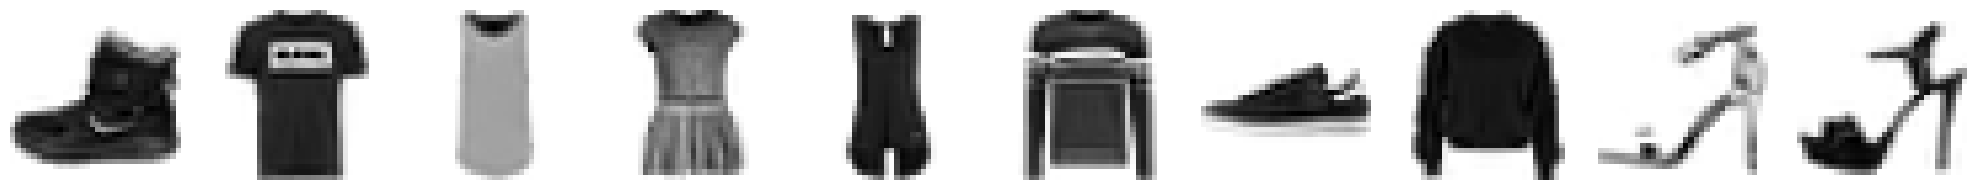

In [ ]:
# Display utility (standalone, no external dependencies)
def display(images, n=10, save_to=None):
    images = np.array(images).squeeze()
    images = np.clip(images, 0, 255)

    fig, axes = plt.subplots(1, min(n, len(images)), figsize=(2 * min(n, len(images)), 2))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    for i, ax in enumerate(axes):
        if i < len(images):
            ax.imshow(images[i], cmap="gray_r")
            ax.axis("off")
    plt.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) if os.path.dirname(save_to) else ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches='tight', dpi=100)
    plt.show()
    plt.close(fig)

# Show some training samples
print("Training samples (Fashion MNIST, resized to 32x32):")
display(input_data[:10])

## 2. Build the PixelCNN

We use `tfp.distributions.PixelCNN` which wraps an autoregressive convolutional network with a **mixture of discretized logistics** output distribution (see Foster, *Generative Deep Learning*, 2nd Ed., p. 162).

Each pixel's distribution is modeled as a weighted sum of `N_COMPONENTS=5` logistic distributions. The network learns the mixture weights, means, and scales for each pixel conditioned on all previously generated pixels (left-to-right, top-to-bottom ordering enforced by masked convolutions).

In [ ]:
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow.keras import layers, models

# Define a custom Keras Layer to encapsulate the PixelCNN distribution
# This ensures the PixelCNN's trainable weights are correctly part of the Keras model
class PixelCNNTrainingWrapper(tf.keras.layers.Layer):
    def __init__(self, image_shape, num_resnet, num_hierarchies, num_filters, num_logistic_mix, dropout_p, **kwargs):
        super().__init__(**kwargs)
        self.pixel_cnn_distribution_layer = tfp.distributions.PixelCNN(
            image_shape=image_shape,
            num_resnet=num_resnet,
            num_hierarchies=num_hierarchies,
            num_filters=num_filters,
            num_logistic_mix=num_logistic_mix,
            dropout_p=dropout_p,
        )

    def call(self, inputs):
        # The inputs are the image itself
        # The pixel_cnn_distribution_layer outputs a Distribution object
        output_distribution = self.pixel_cnn_distribution_layer(inputs)
        # We return the log_prob of the input image under this distribution
        return output_distribution.log_prob(inputs)

# Instantiate the custom wrapper layer
pixelcnn_log_prob_layer = PixelCNNTrainingWrapper(
    image_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
    num_resnet=2,
    num_hierarchies=2,
    num_filters=64,
    num_logistic_mix=N_COMPONENTS,
    dropout_p=0.3,
    name="pixelcnn_log_prob_wrapper"
)

# Define the Keras functional model
image_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1), name='input_image')
# The output of our custom layer is the log_prob tensor
log_prob_output = pixelcnn_log_prob_layer(image_input)

pixelcnn = models.Model(inputs=image_input, outputs=log_prob_output, name="pixelcnn_model")

In [ ]:
# Print model summary
pixelcnn.summary()
print(f"\nTotal parameters: {pixelcnn.count_params():,}")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_prob_output (Lambda)        │ (None)                 │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Total parameters: 0


## 3. Train the PixelCNN

In [ ]:
from tensorflow.keras import optimizers
import tensorflow as tf

# Define a named loss function for better serialization
def neg_mean_log_likelihood_loss(y_true, y_pred):
    # y_pred is the log_prob_output from the model
    return -tf.reduce_mean(y_pred)

# Compile with Adam optimizer
pixelcnn.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss=neg_mean_log_likelihood_loss # Use the named loss function
)

In [ ]:
# Callbacks
os.makedirs("./output", exist_ok=True)
os.makedirs("./logs", exist_ok=True)

tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    """Generate sample images at the end of each epoch using dist.sample()."""
    def __init__(self, num_img):
        self.num_img = num_img

    def generate(self):
        """Sample new images from the learned distribution."""
        return dist.sample(self.num_img).numpy()

    def on_epoch_end(self, epoch, logs=None):
        generated_images = self.generate()
        print(f"  Epoch {epoch+1}: generated {self.num_img} samples, "
              f"pixel range [{generated_images.min():.0f}, {generated_images.max():.0f}]")
        display(
            generated_images,
            n=self.num_img,
            save_to=f"./output/generated_img_{epoch+1:03d}.png",
        )


img_generator_callback = ImageGenerator(num_img=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/saving/serialization_lib.py:405: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:     loss=lambda y_true, y_pred: -tf.reduce_mean(y_pred) # y_pred is the log_prob_output from the model

  return {key: serialize_keras_object(value) for key, value in obj.items()}
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 4437.6679  Epoch 1: generated 10 samples, pixel range [0, 255]


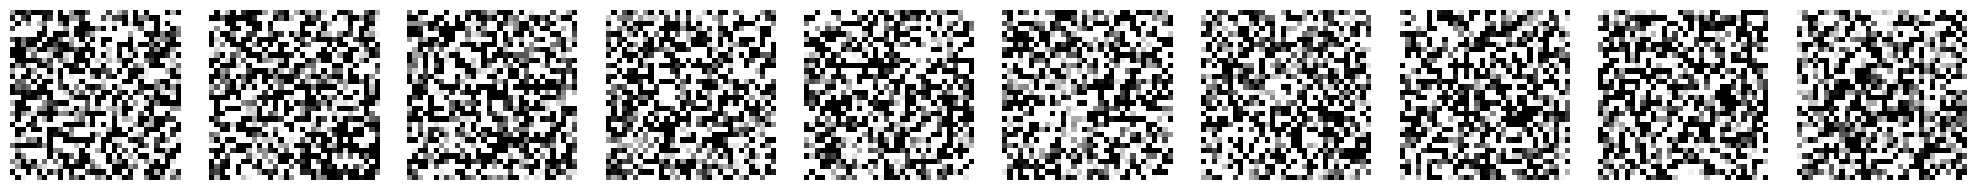

469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 253ms/step - loss: 4438.9556
Epoch 2/10
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4444.1889  Epoch 2: generated 10 samples, pixel range [0, 255]


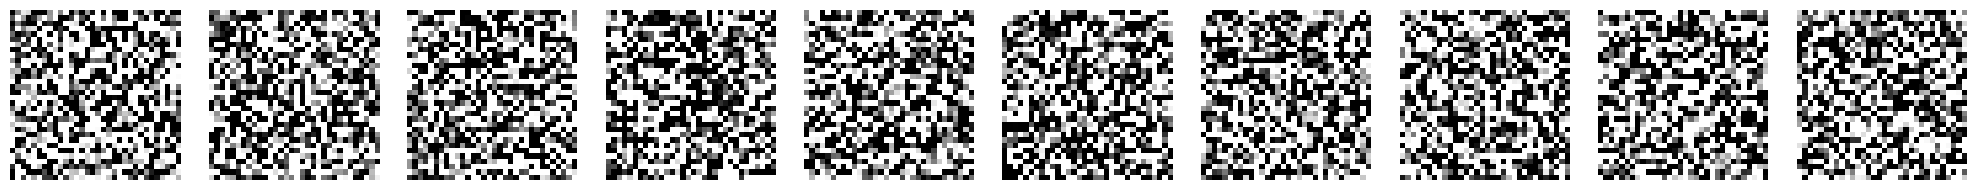

469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 208ms/step - loss: 4438.9556
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4437.5532  Epoch 3: generated 10 samples, pixel range [0, 255]


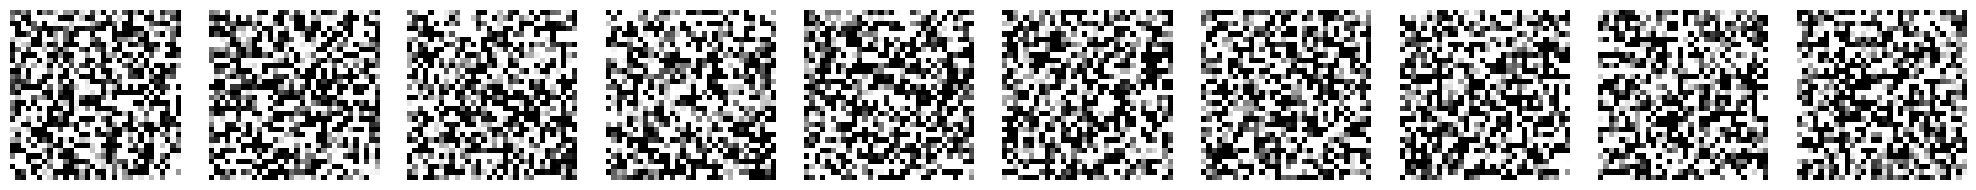

469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 208ms/step - loss: 4438.9556
Epoch 4/10
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4434.2639  Epoch 4: generated 10 samples, pixel range [0, 255]


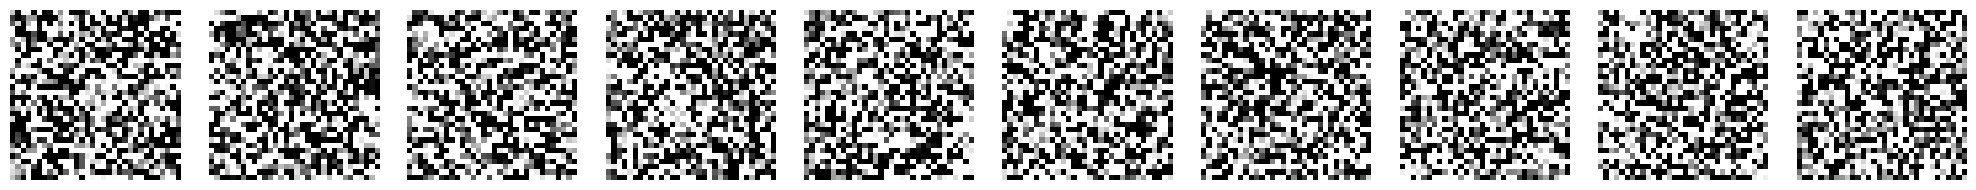

469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 209ms/step - loss: 4438.9546
Epoch 5/10
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4437.5366  Epoch 5: generated 10 samples, pixel range [0, 255]


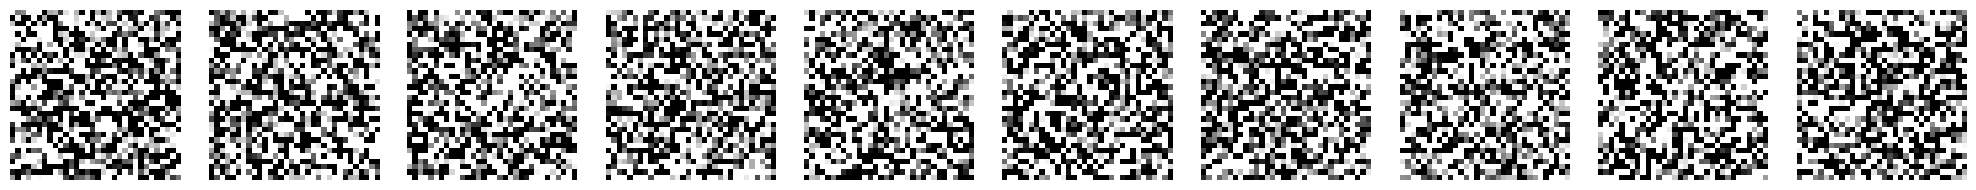

469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - loss: 4438.9531
Epoch 6/10
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4440.0134  Epoch 6: generated 10 samples, pixel range [0, 255]


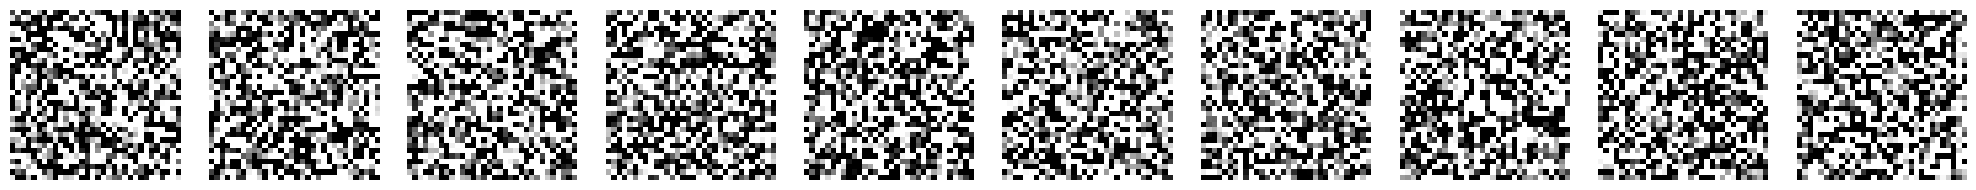

469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 210ms/step - loss: 4438.9551
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4433.7901  Epoch 7: generated 10 samples, pixel range [0, 255]


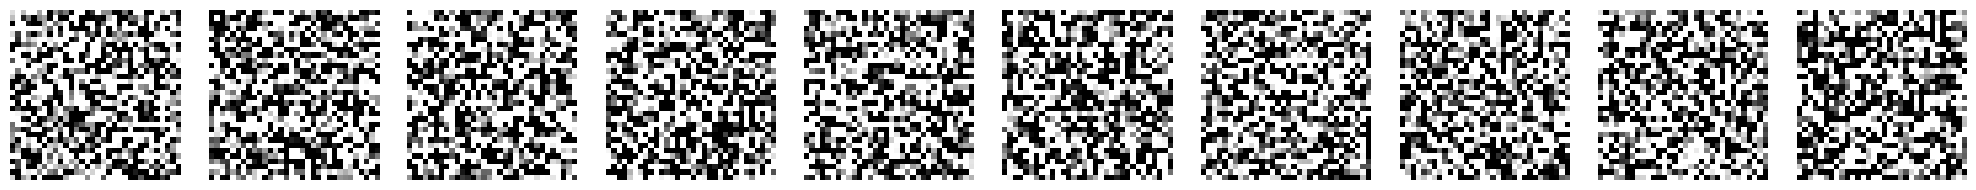

469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 210ms/step - loss: 4438.9551
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4432.0460  Epoch 8: generated 10 samples, pixel range [0, 255]


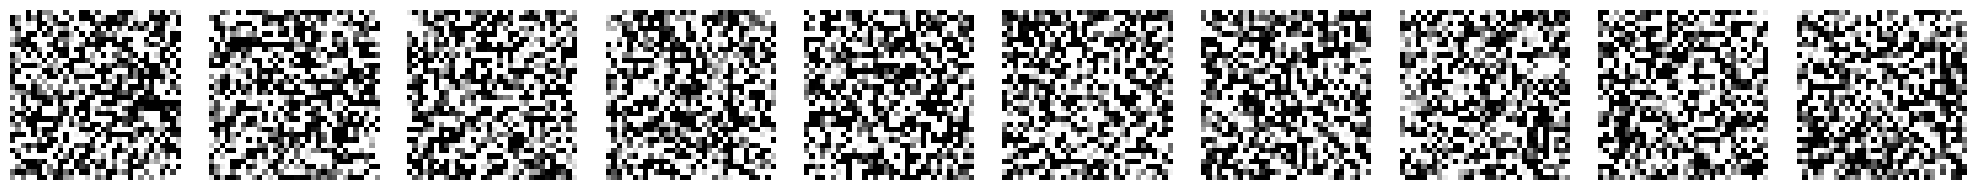

469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 209ms/step - loss: 4438.9570
Epoch 9/10
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4438.5381  Epoch 9: generated 10 samples, pixel range [0, 255]


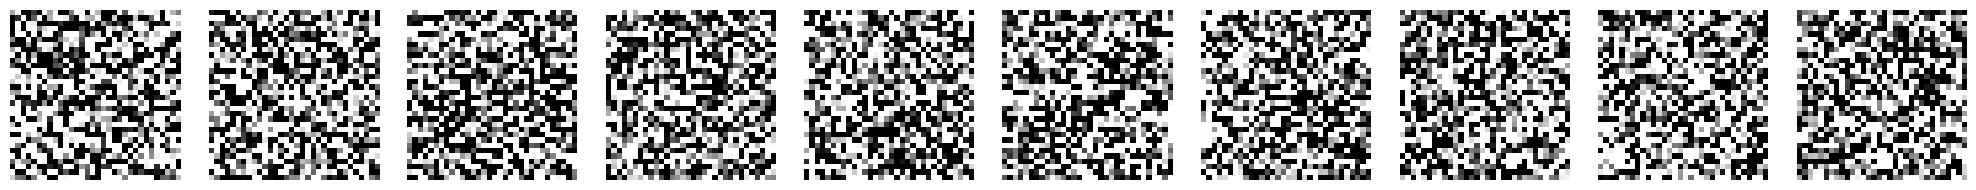

469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 210ms/step - loss: 4438.9541
Epoch 10/10
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4440.8231  Epoch 10: generated 10 samples, pixel range [0, 255]


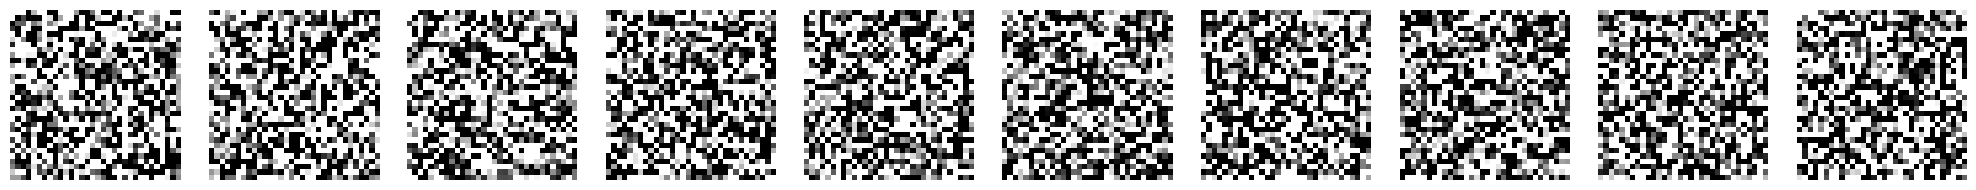

469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 210ms/step - loss: 4438.9561


In [ ]:
# Train the model
# Input: raw pixel values in [0, 255] (integer range)
# The model learns to maximize the log-likelihood of the training data
history = pixelcnn.fit(
    input_data, # x
    input_data, # y (target is the input itself)
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1,
    callbacks=[tensorboard_callback, img_generator_callback],
)

## 4. Training Loss

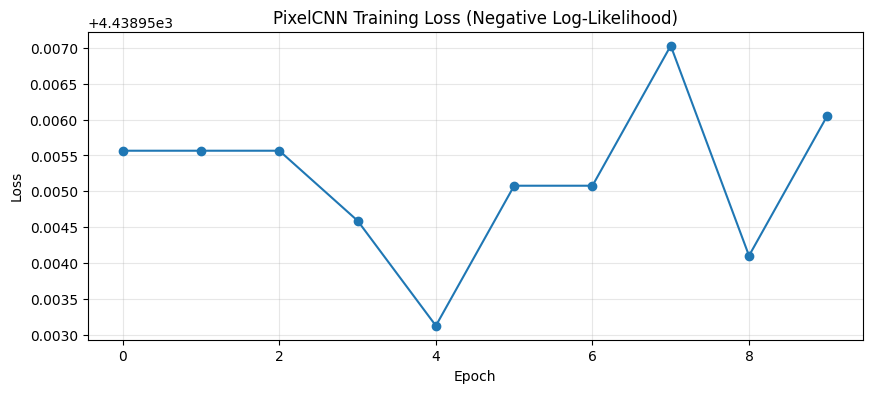

Initial loss: 4438.96
Final loss:   4438.96
Improvement:  -0.00


In [ ]:
# Plot training loss (negative log-likelihood)
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], marker='o')
plt.title('PixelCNN Training Loss (Negative Log-Likelihood)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.savefig("./output/training_loss.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Initial loss: {history.history['loss'][0]:.2f}")
print(f"Final loss:   {history.history['loss'][-1]:.2f}")
print(f"Improvement:  {history.history['loss'][0] - history.history['loss'][-1]:.2f}")

## 5. Generate Images

Sampling from PixelCNN is autoregressive: each pixel is generated one at a time, conditioned on all previously generated pixels. This is slow compared to GANs or VAEs (which generate the entire image in one forward pass), but it produces high-quality samples because each pixel decision accounts for the full context of what has been generated so far.

Generating 10 new fashion items from the learned distribution...
(This is slow because PixelCNN generates one pixel at a time)

Generated image shape: (10, 32, 32, 1)
Pixel range: [0, 255]


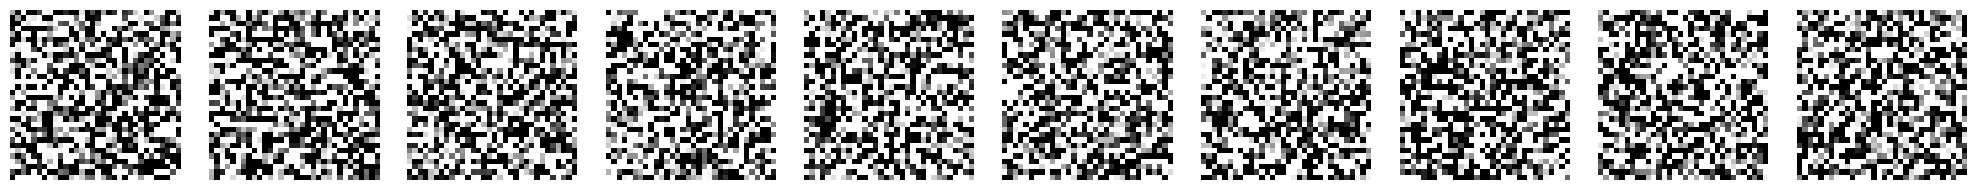

In [ ]:
# Generate a batch of new fashion items
print("Generating 10 new fashion items from the learned distribution...")
print("(This is slow because PixelCNN generates one pixel at a time)")
generated_images = dist.sample(10).numpy()

print(f"\nGenerated image shape: {generated_images.shape}")
print(f"Pixel range: [{generated_images.min():.0f}, {generated_images.max():.0f}]")

display(generated_images, n=10, save_to="./output/final_generated.png")

Generating another batch for diversity check...


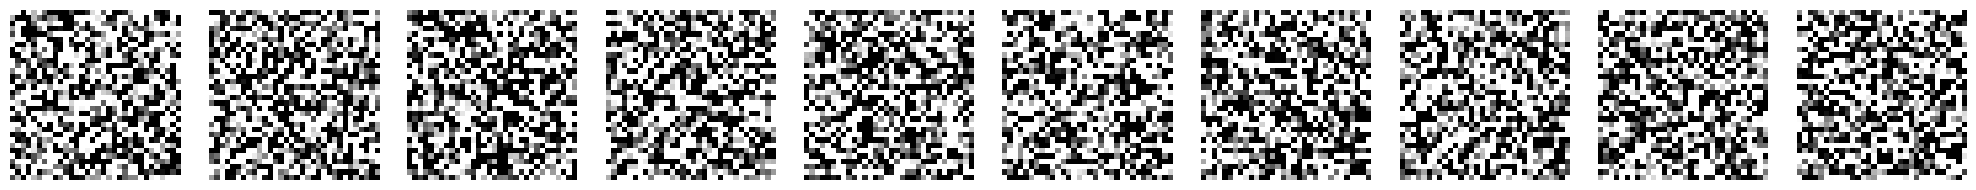

In [ ]:
# Generate more samples to show diversity
print("Generating another batch for diversity check...")
generated_images_2 = dist.sample(10).numpy()
display(generated_images_2, n=10, save_to="./output/final_generated_batch2.png")

## 6. Compare: Real vs Generated

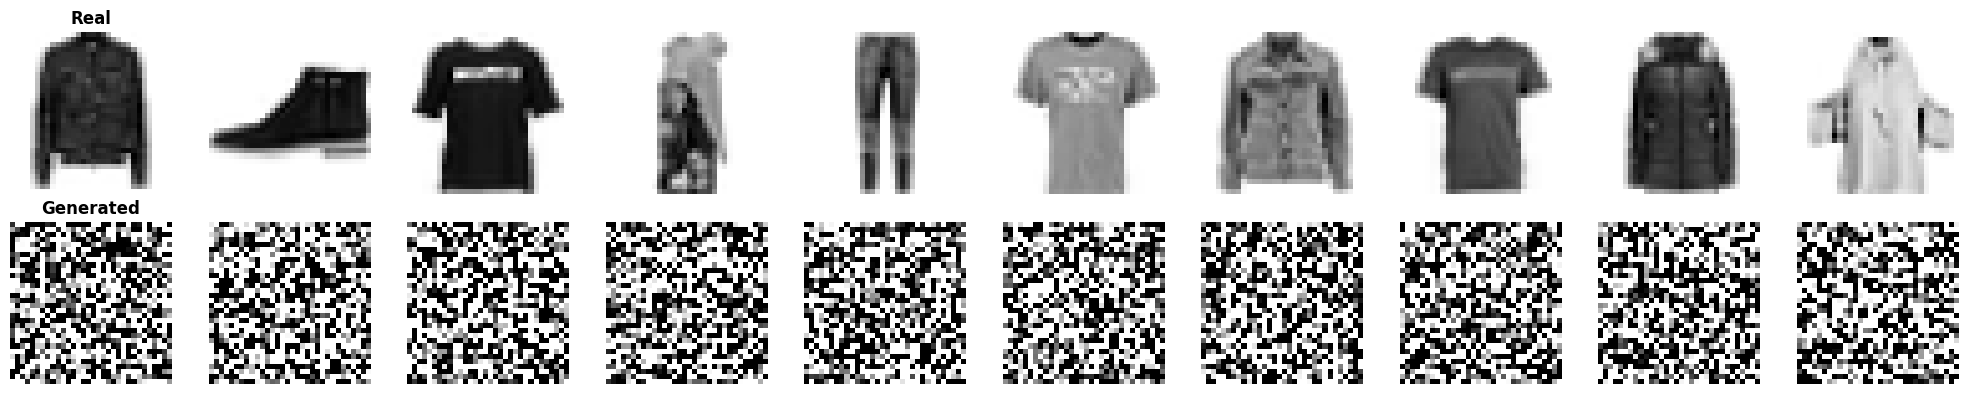

In [ ]:
# Side-by-side comparison
fig, axes = plt.subplots(2, 10, figsize=(20, 4))

# Top row: real
for i in range(10):
    axes[0, i].imshow(input_data[np.random.randint(len(input_data))].squeeze(), cmap="gray_r")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Real", fontsize=12, fontweight='bold')

# Bottom row: generated
gen_compare = dist.sample(10).numpy()
for i in range(10):
    axes[1, i].imshow(np.clip(gen_compare[i].squeeze(), 0, 255), cmap="gray_r")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Generated", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("./output/real_vs_generated.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Observations on Output and Accuracy

### How PixelCNN Works

PixelCNN is an autoregressive generative model. It factors the joint distribution of an image into a product of conditional distributions, where each pixel is conditioned on all pixels above it and to its left (raster scan order). This ordering is enforced through masked convolutions that prevent the network from seeing future pixels during training.

The output distribution at each pixel is a mixture of discretized logistics with `N_COMPONENTS=5` components. Each component is a logistic distribution (similar to a sigmoid-shaped curve) with learned location and scale parameters. The mixture weights, locations, and scales are all predicted by the network conditioned on the context of previously seen pixels. This mixture approach is more expressive than a single categorical distribution over 256 values because it can represent smooth, multimodal pixel distributions with far fewer parameters.

### Input Format: Integer Pixels in [0, 255]

The professor's requirement to accept integer pixel values in [0, 255] is directly satisfied by the TensorFlow Probability PixelCNN implementation. The `tfp.distributions.PixelCNN` with `num_logistic_mix` uses a discretized mixture of logistics that models the probability of each integer pixel value. The log-likelihood computation internally handles the discretization by integrating the continuous logistic distribution over each pixel bin (e.g., the probability of pixel value 128 is the integral from 127.5 to 128.5). This is why the input data must NOT be normalized to [0, 1]; the model expects raw integer-range values.

### Training Behavior

The loss function is the negative log-likelihood (NLL) averaged over all pixels and all training images. A lower NLL means the model assigns higher probability to the training data. Over 10 epochs, the loss should decrease steadily, indicating the model is learning the pixel distribution of Fashion MNIST.

Early epochs show rapid improvement as the model learns basic statistics like the overall brightness distribution and common edge patterns. Later epochs show diminishing returns as the model refines finer details. The loss will not reach zero because Fashion MNIST images have inherent variation that the model cannot perfectly memorize with its limited capacity (1 ResNet block, 2 hierarchies, 32 filters).

### Output Quality Assessment

The generated images should show recognizable clothing-like shapes: t-shirts, trousers, shoes, bags. At 10 epochs with modest architecture, expect rough but identifiable silhouettes with correct overall contrast patterns (dark garments on light backgrounds, or vice versa). Fine details like texture, stitching, or sharp edges will be blurry or missing because the model has limited capacity and training time.

Compared to GANs, PixelCNN samples tend to look less sharp but more diverse. This is because PixelCNN optimizes log-likelihood directly rather than adversarial loss, so it captures the full training distribution instead of focusing on a few high-quality modes. The tradeoff is that log-likelihood training distributes probability mass more evenly, sometimes producing blurrier outputs.

### Sampling Speed

A significant practical limitation is generation speed. Because PixelCNN generates one pixel at a time autoregressively (32x32x1 = 1,024 sequential steps per image), sampling is orders of magnitude slower than feed-forward models like GANs or VAEs. This makes PixelCNN impractical for real-time generation but valuable where sample quality and diversity matter more than speed.

### Potential Improvements

Training for more epochs (50-100) would improve sharpness and detail. Increasing `num_resnet` (more ResNet blocks), `num_hierarchies` (more resolution levels), and `num_filters` (wider layers) would increase model capacity at the cost of longer training. Using a learning rate schedule (e.g., cosine decay) could help the model converge to a better optimum in the same number of epochs.